# ML Lab 4: Linear Regression on Heart Disease Dataset

In this lab, we will apply Linear Regression to the Cleveland Heart Disease dataset. Although `num` (the target) is categorical (0-4), we will treat it as a continuous variable for the purpose of this regression exercise, predicting the severity of heart disease.

In [4]:
# Install necessary libraries if they are not already installed
%pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.Collecting pandas
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.7 MB 3.7 MB/s eta 0:00:03
   ------- -------------------------------- 1.8/9.7 MB 4.4 MB/s eta 0:00:02
   ----------- ---------------------------- 2.9/9.7 MB 4.4 MB/s eta 0:00:02
   --------------- ------------------------ 3.7/9.7 MB 4.4 MB/s eta 0:00:02
   -------------------- ------------------- 5.0/9.7 MB 4.6 MB/s eta 0:00:02
   ----------------------- ---------------- 5.8/9.7 MB 4.6 MB/s eta 0:00:01
   ---------------------------- ----------- 6.8/9.7 MB 4.6 MB/s eta 0:00:01
   -------------------------------- ------- 7.9/9.7 MB 4.6 MB/s eta 0:00:01
   ------------------------------------ --

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.3.1 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load the Data
# The data file does not contain a header, so we define column names manually based on the documentation.
columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'
]

df = pd.read_csv('processed.cleveland.data', names=columns)

# Display first few rows
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [6]:
# 2. Preprocessing
# The dataset contains '?' for missing values. We replace them with NaN and drop rows with missing values for simplicity.
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)

# Ensure all columns are numeric
df = df.apply(pd.to_numeric)

# Check info to verify types and non-null counts
df.info()

<class 'pandas.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    float64
 1   sex       297 non-null    float64
 2   cp        297 non-null    float64
 3   trestbps  297 non-null    float64
 4   chol      297 non-null    float64
 5   fbs       297 non-null    float64
 6   restecg   297 non-null    float64
 7   thalach   297 non-null    float64
 8   exang     297 non-null    float64
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    float64
 11  ca        297 non-null    float64
 12  thal      297 non-null    float64
 13  num       297 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 34.8 KB


In [7]:
# 3. Linear Regression Analysis

# Define features (X) and target (y)
# We will use all available features to predict 'num' (severity of heart disease)
X = df.drop('num', axis=1)
y = df['num']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared Score: {r2:.4f}")

Mean Squared Error: 0.8204
R-squared Score: 0.4815


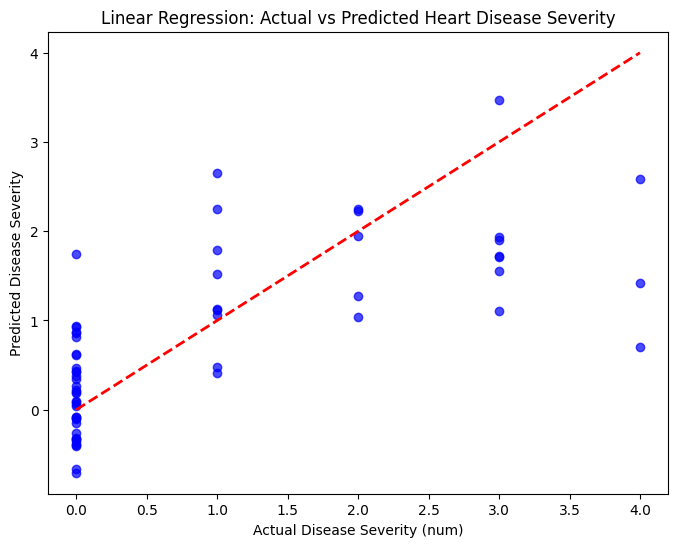

In [8]:
# 4. Visualization
# Plot Actual vs Predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Identity line
plt.xlabel('Actual Disease Severity (num)')
plt.ylabel('Predicted Disease Severity')
plt.title('Linear Regression: Actual vs Predicted Heart Disease Severity')
plt.show()

In [9]:
# Inspect Coefficients to see which features impact the prediction most
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
coef_df.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
11,ca,0.434349
1,sex,0.275041
2,cp,0.208527
9,oldpeak,0.156839
10,slope,0.136849
8,exang,0.131438
6,restecg,0.122870
12,thal,0.113095
3,trestbps,0.008817
4,chol,0.000627
